# MScFE 622 — Stochastic Modeling
## Group Work Project #2: HMM Regime Allocation



### Analytical scope

This notebook is the canonical technical artifact for the HMM-only revision. The only regime model used in Steps 2–5 is a **Gaussian Hidden Markov Model (HMM)** fitted to daily changes in the VIX. We evaluate exactly two state counts, $K=2$ and $K=3$, select between valid candidates by BIC, construct both assignment allocation rules (**100% Keep** and **60/40 Spread**), and compare both HMM strategies with the required monthly equal-weight and SPY buy-and-hold benchmarks.

All numerical tables and figures below are rendered from committed canonical artifacts generated from `data/processed/step1_data.csv`. Analytical calculations are kept outside the notebook so that the notebook remains a presentation and orchestration layer.


In [1]:
from vix_regime_allocation import notebook_helpers as nb


In [2]:
from vix_regime_allocation import notebook_sensitivity as sensitivity_nb


# Step 1 — Canonical input sample

The revision does not re-download data. The common input is the committed Step 1 dataset containing TLT, GLD, SPY, VIX, their ETF log returns, and the daily VIX change. All later model fitting, state statistics, allocations, backtests, and sensitivity calculations use this same date-indexed sample.

VIX is an options-implied measure designed to summarize the market's expectation of near-term S&P 500 volatility, so changes in VIX provide a natural single observation series for a volatility-regime model (Whaley 98–105).


In [3]:
nb.step_1_data_overview()


### Step 1 — Common sample and transformed series

,TLT,GLD,SPY,VIX,TLT_log_return,GLD_log_return,SPY_log_return,VIX_change
Date,,,,,,,,
2004-11-19 00:00:00,43.302605,44.779999,78.858780,13.50,-0.80%,0.90%,-1.12%,0.52
2004-11-22 00:00:00,43.528297,44.950001,79.234833,12.97,0.52%,0.38%,0.48%,-0.53
2004-11-23 00:00:00,43.582287,44.750000,79.355743,12.67,0.12%,-0.45%,0.15%,-0.30
2004-11-24 00:00:00,43.582287,45.049999,79.543793,12.72,0.00%,0.67%,0.24%,0.05
2004-11-26 00:00:00,43.297714,45.290001,79.483330,12.78,-0.66%,0.53%,-0.08%,0.06


,series,count,mean,std,min,25%,50%,75%,max
0,TLT_log_return,"5,465",0.01%,0.92%,-6.90%,-0.53%,0.04%,0.55%,7.25%
1,GLD_log_return,"5,465",0.04%,1.15%,-10.84%,-0.52%,0.06%,0.63%,10.70%
2,SPY_log_return,"5,465",0.04%,1.19%,-11.59%,-0.39%,0.07%,0.58%,13.56%
3,VIX_change,"5,465",0.00,1.90,-18.71,-0.72,-0.10,0.57,24.86


# Step 2 — Gaussian Hidden Markov Models

## 2.1 Latent-state model

An HMM assumes that the observed series is generated by an **unobserved first-order state process**. Let $S_t$ be the latent state on date $t$ and $X_t$ the observed daily VIX change. Conditional on $S_t$, the observation distribution is Gaussian; dependence across dates enters through state-transition probabilities. This separates persistent latent regimes from noisy observed movements (Rabiner 257–286).

**Greek letters used in the next equation**

- $\pi$ — **pi** — initial-state probability.
- $\mu$ — **mu** — state-conditional mean.
- $\sigma$ — **sigma** — state-conditional standard deviation.

$$
P(S_1=j)=\pi_j,\qquad
P(S_t=j\mid S_{t-1}=i)=a_{ij},\qquad
X_t\mid S_t=j \sim \mathcal{N}(\mu_j,\sigma_j^2).
$$

The parameter set therefore consists of initial-state probabilities, a row-stochastic transition matrix, state-specific means, and state-specific variances. In this project the emission covariance is diagonal, the observation is one-dimensional `VIX_change`, and candidate state counts are exactly $K=2$ and $K=3$.

## 2.2 Observed-data likelihood

The latent state path is not observed, so the likelihood sums over every possible state sequence. The forward recursion evaluates this sum efficiently rather than enumerating all paths (Rabiner 257–286).

$$
L = \sum_{s_1,\ldots,s_T}
P(S_1=s_1)
\prod_{t=2}^{T}P(S_t=s_t\mid S_{t-1}=s_{t-1})
\prod_{t=1}^{T} f(X_t\mid S_t=s_t).
$$

## 2.3 Expectation-Maximization / Baum-Welch estimation

Baum-Welch is the HMM-specific Expectation-Maximization procedure. The **E-step** uses forward-backward probabilities to compute posterior responsibilities for individual states and adjacent state transitions. The **M-step** re-estimates initial probabilities, transition probabilities, Gaussian means, and variances from those responsibilities. The two steps repeat until the configured convergence criterion is met (Baum et al. 164–171; Rabiner 257–286).

**Greek letters used in the next equation**

- $\gamma$ — **gamma** — posterior probability that one state is occupied at a date.
- $\xi$ — **xi** — posterior probability of one adjacent state transition.

$$
\gamma_t(j)=P(S_t=j\mid X_{1:T}),\qquad
\xi_t(i,j)=P(S_t=i,S_{t+1}=j\mid X_{1:T}).
$$

**Greek letters used in the next equation**

- $\pi$ — **pi** — initial-state probability.
- $\mu$ — **mu** — state-conditional mean.
- $\sigma$ — **sigma** — state-conditional standard deviation.
- $\gamma$ — **gamma** — state responsibility.
- $\xi$ — **xi** — transition responsibility.

$$
\pi_j^{new}=\gamma_1(j),\qquad
a_{ij}^{new}=
\frac{\sum_{t=1}^{T-1}\xi_t(i,j)}
{\sum_{t=1}^{T-1}\gamma_t(i)},\qquad
\mu_j^{new}=
\frac{\sum_{t=1}^{T}\gamma_t(j)X_t}
{\sum_{t=1}^{T}\gamma_t(j)},\qquad
(\sigma_j^2)^{new}=
\frac{\sum_{t=1}^{T}\gamma_t(j)(X_t-\mu_j^{new})^2}
{\sum_{t=1}^{T}\gamma_t(j)}.
$$

Expectation-Maximization can converge to a local optimum rather than the global optimum. For that reason the project fits a deterministic set of starting seeds for each $K$, keeps converged finite-likelihood fits, chooses the greatest likelihood, and resolves a likelihood tie with the smallest seed (Baum et al. 164–171; Rabiner 257–286). State labels are then normalized by increasing fitted mean VIX change so that state identities are reproducible.

## 2.4 Viterbi path versus smoothed probabilities

The **Viterbi sequence** solves a joint decoding problem: it is the single most likely complete latent-state path conditional on the observed sequence (Viterbi 260–269; Rabiner 257–286). It is not the same object as selecting the largest posterior state probability independently at each date.

Smoothed state probabilities instead report $P(S_t=j\mid X_{1:T})$: each historical probability conditions on the **entire sample**, including observations after date $t$. They are valuable for retrospective description but are non-causal for historical dates. The fitted-state figures below therefore describe the full-sample regime structure; they are not real-time forecasts.


,state,mean_vix_change,variance_vix_change,start_probability,viterbi_observations,viterbi_occupancy,posterior_mean_probability
0,0,-0.07,0.65,100.00%,4159,76.10%,73.94%
1,1,0.21,11.96,0.00%,1306,23.90%,26.06%


,from_state,state_0,state_1
0,0,95.87%,4.13%
1,1,11.71%,88.29%


,state,mean_vix_change,variance_vix_change,start_probability,viterbi_observations,viterbi_occupancy,posterior_mean_probability
0,0,-0.06,0.38,100.00%,2900,53.06%,52.18%
1,1,-0.01,3.12,0.00%,2306,42.20%,42.11%
2,2,0.66,36.35,0.00%,259,4.74%,5.71%


,from_state,state_0,state_1,state_2
0,0,93.89%,5.98%,0.14%
1,1,7.57%,90.86%,1.57%
2,2,0.00%,12.82%,87.18%


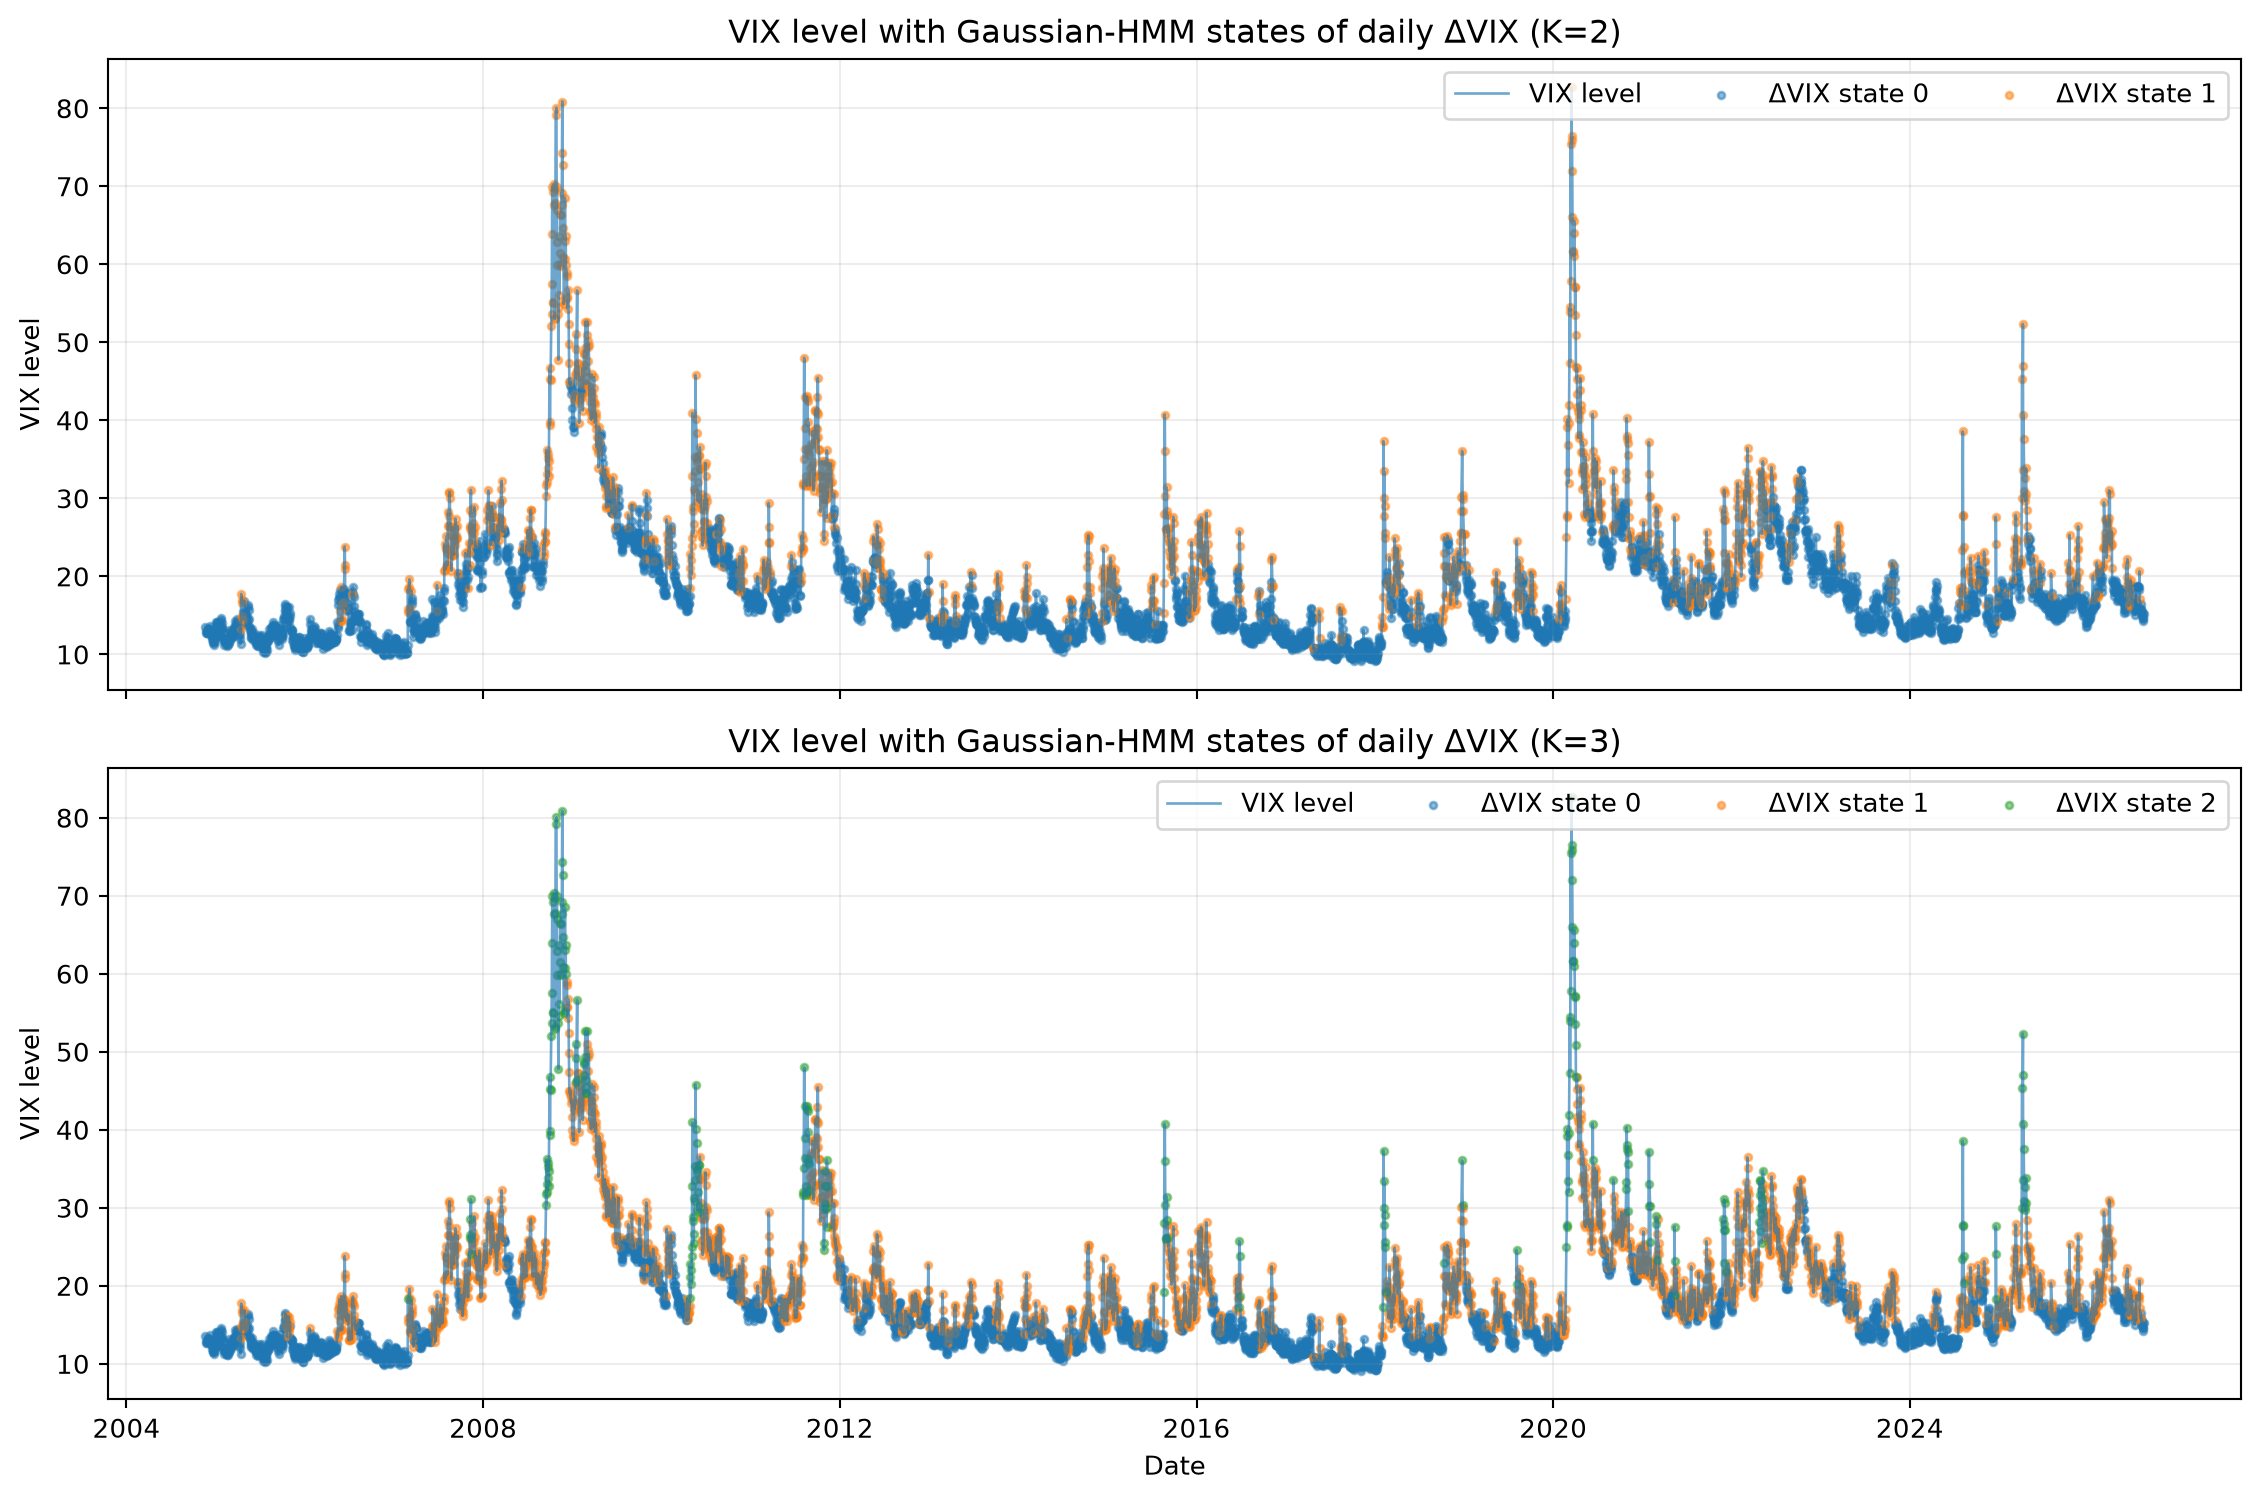

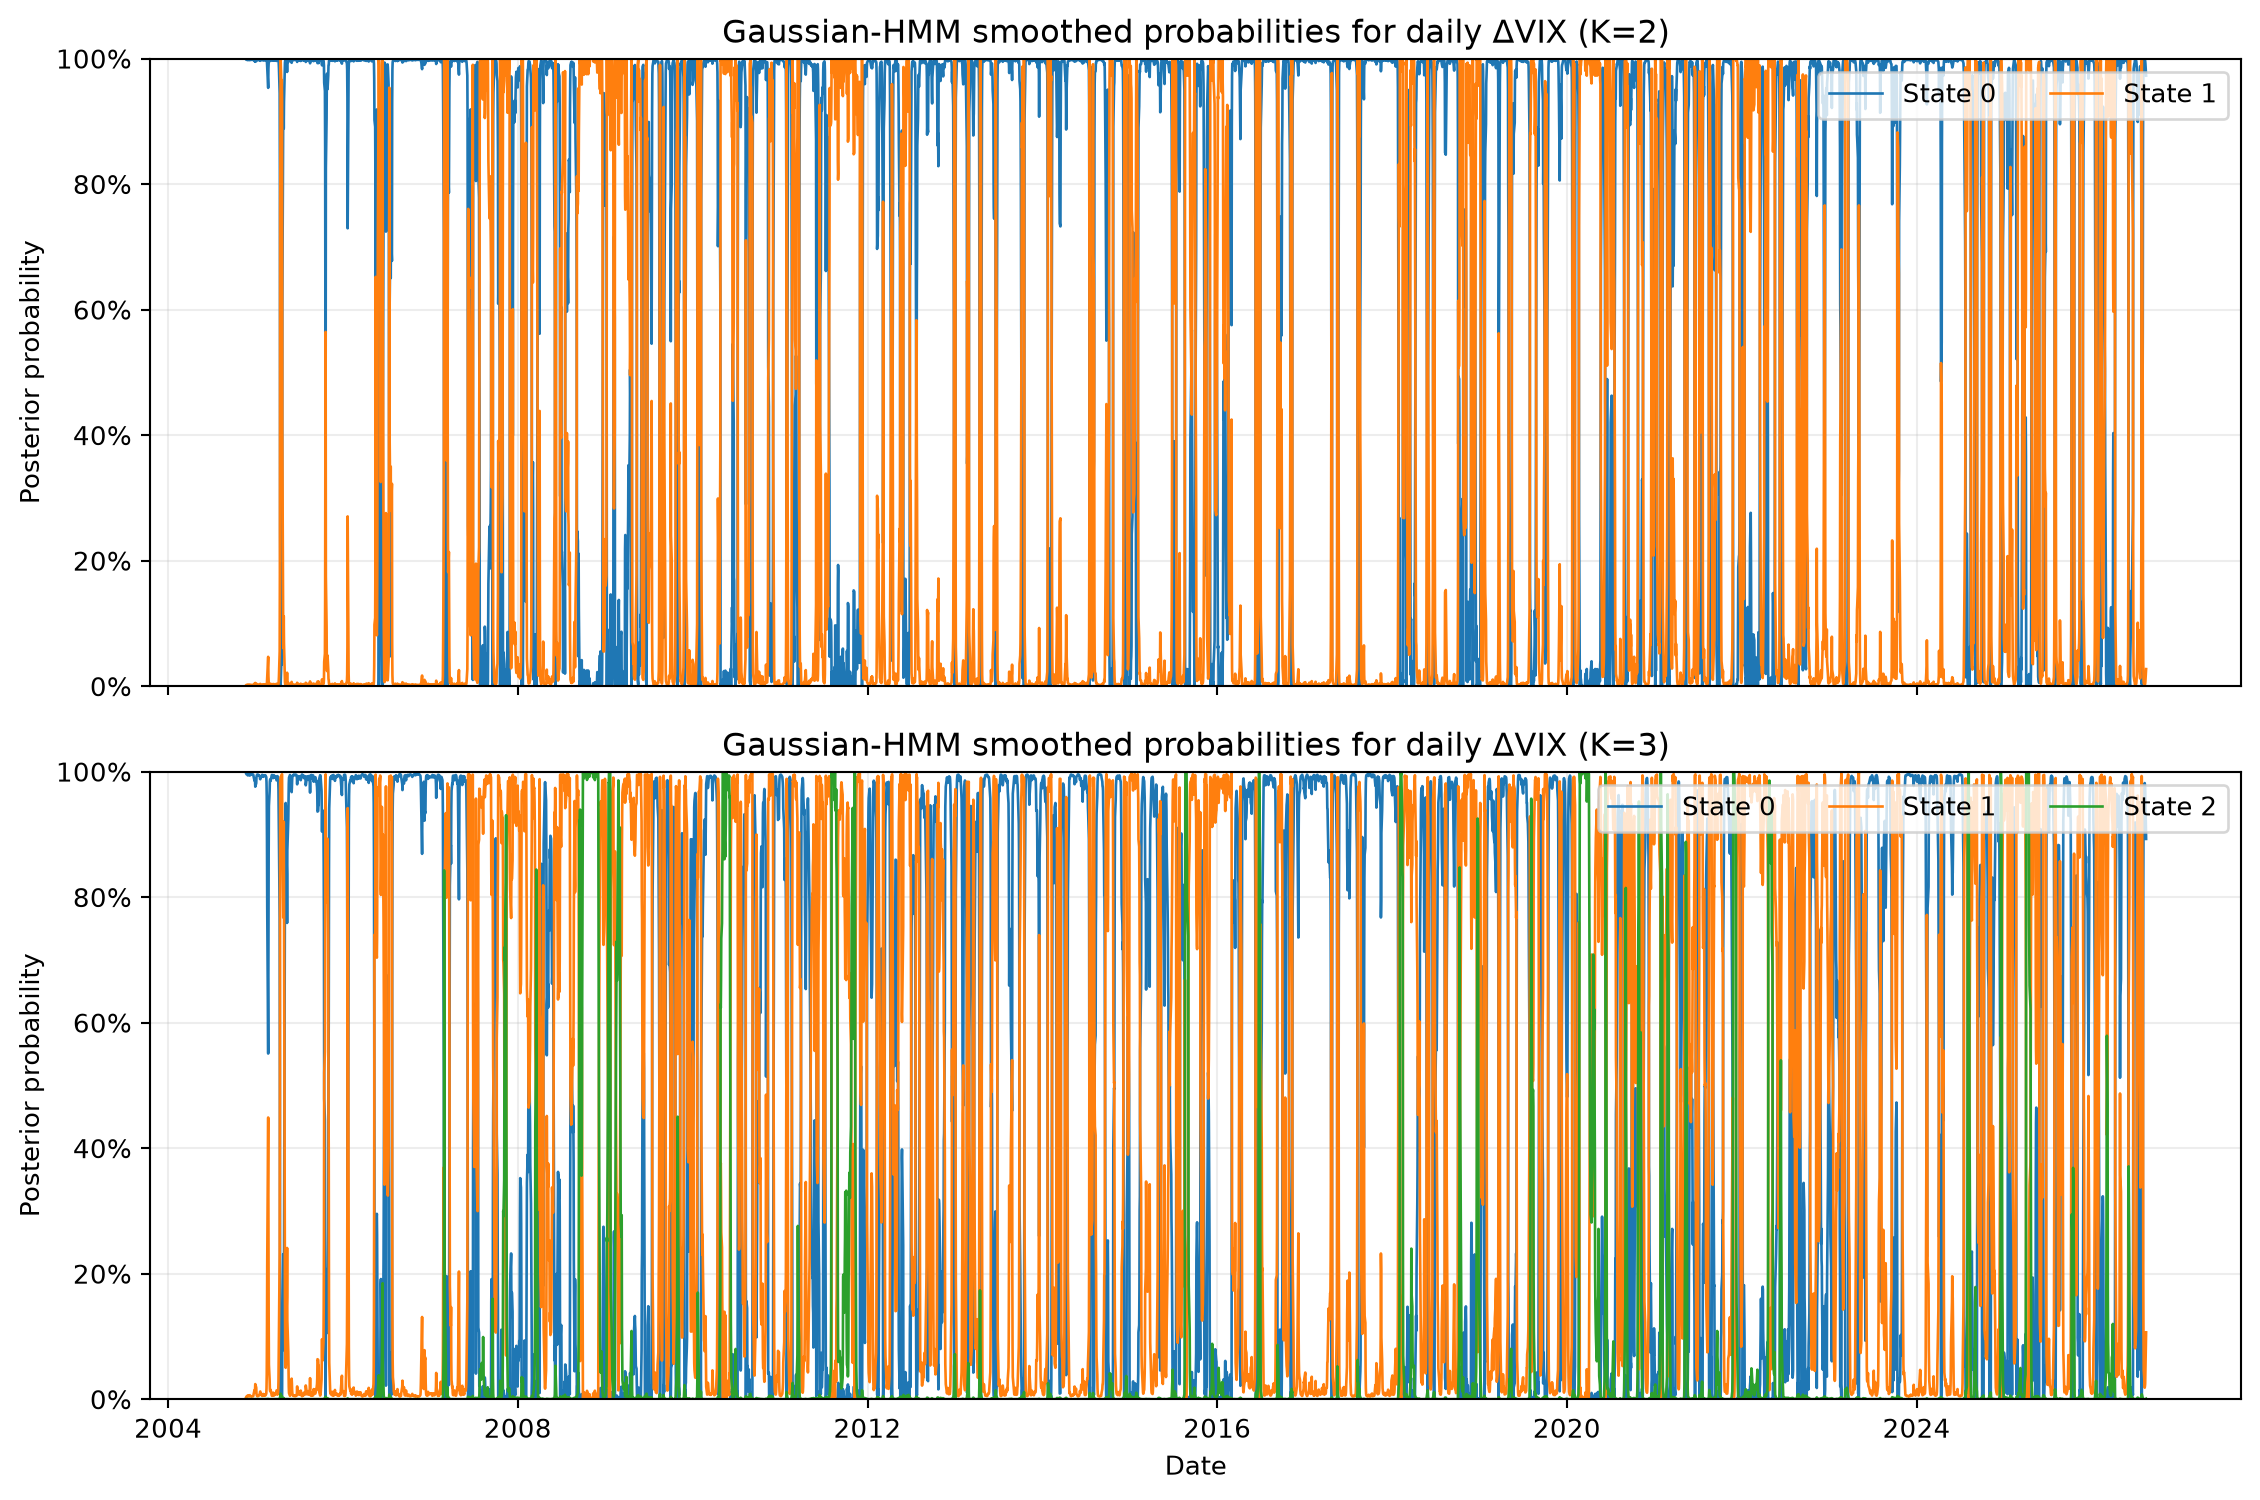

In [4]:
nb.step_2_hmm_diagnostics()


# Step 3 — HMM state-count selection

The comparison is restricted to the two HMM candidates. For $K$ states, the project counts $K^2+2K-1$ free parameters. A candidate is valid only when convergence, finite parameters and likelihood, probability normalization, Viterbi-label validity, and the project minimum state-occupancy rule all hold.

AIC penalizes likelihood by twice the parameter count (Akaike 716–723):

$$
AIC = 2k - 2\log L.
$$

BIC uses the sample-size-dependent penalty proposed by Schwarz (Schwarz 461–464):

$$
BIC = k\log n - 2\log L.
$$

The preferred model is the **valid HMM candidate with the smallest BIC**; a BIC tie within the fixed numerical tolerance selects the lower state count. The 5% minimum Viterbi occupancy threshold is a project stability rule, not a statistical theorem. If neither candidate is valid, the pipeline fails rather than falling back to another model family.


### Step 3 — HMM-only model selection

,family,n_states,log_likelihood,n_parameters,n_observations,aic,bic,converged,min_viterbi_occupancy,valid
0,hmm,2,-9306.00,7,5465,18626.01,18672.25,True,23.90%,True
1,hmm,3,-8959.53,14,5465,17947.07,18039.56,True,4.74%,False


,selection_field,value
0,family,hmm
1,input_data_sha256,554df7352a6cbd61c063f4bca8f6b0666307c45f73abb269479adf129f380bbb
2,n_states,2
3,selected_states_path,reports/tables/step3_selected_states.csv
4,selection_reason,"Among valid HMM candidates, BIC selected K=2; a BIC tie within tolerance is resolved toward the lower state count."
5,state_source,reports/tables/step2_hmm_2_states.csv


,Date,state
0,2004-11-19 00:00:00,0
1,2004-11-22 00:00:00,0
2,2004-11-23 00:00:00,0
3,2004-11-24 00:00:00,0
4,2004-11-26 00:00:00,0


,state,asset,mean_log_return,std_log_return,observations
0,0,TLT,-0.01%,0.79%,4159
1,0,GLD,0.03%,1.01%,4159
2,0,SPY,0.12%,0.71%,4159
3,1,TLT,0.09%,1.24%,1306
4,1,GLD,0.06%,1.50%,1306
5,1,SPY,-0.21%,2.06%,1306


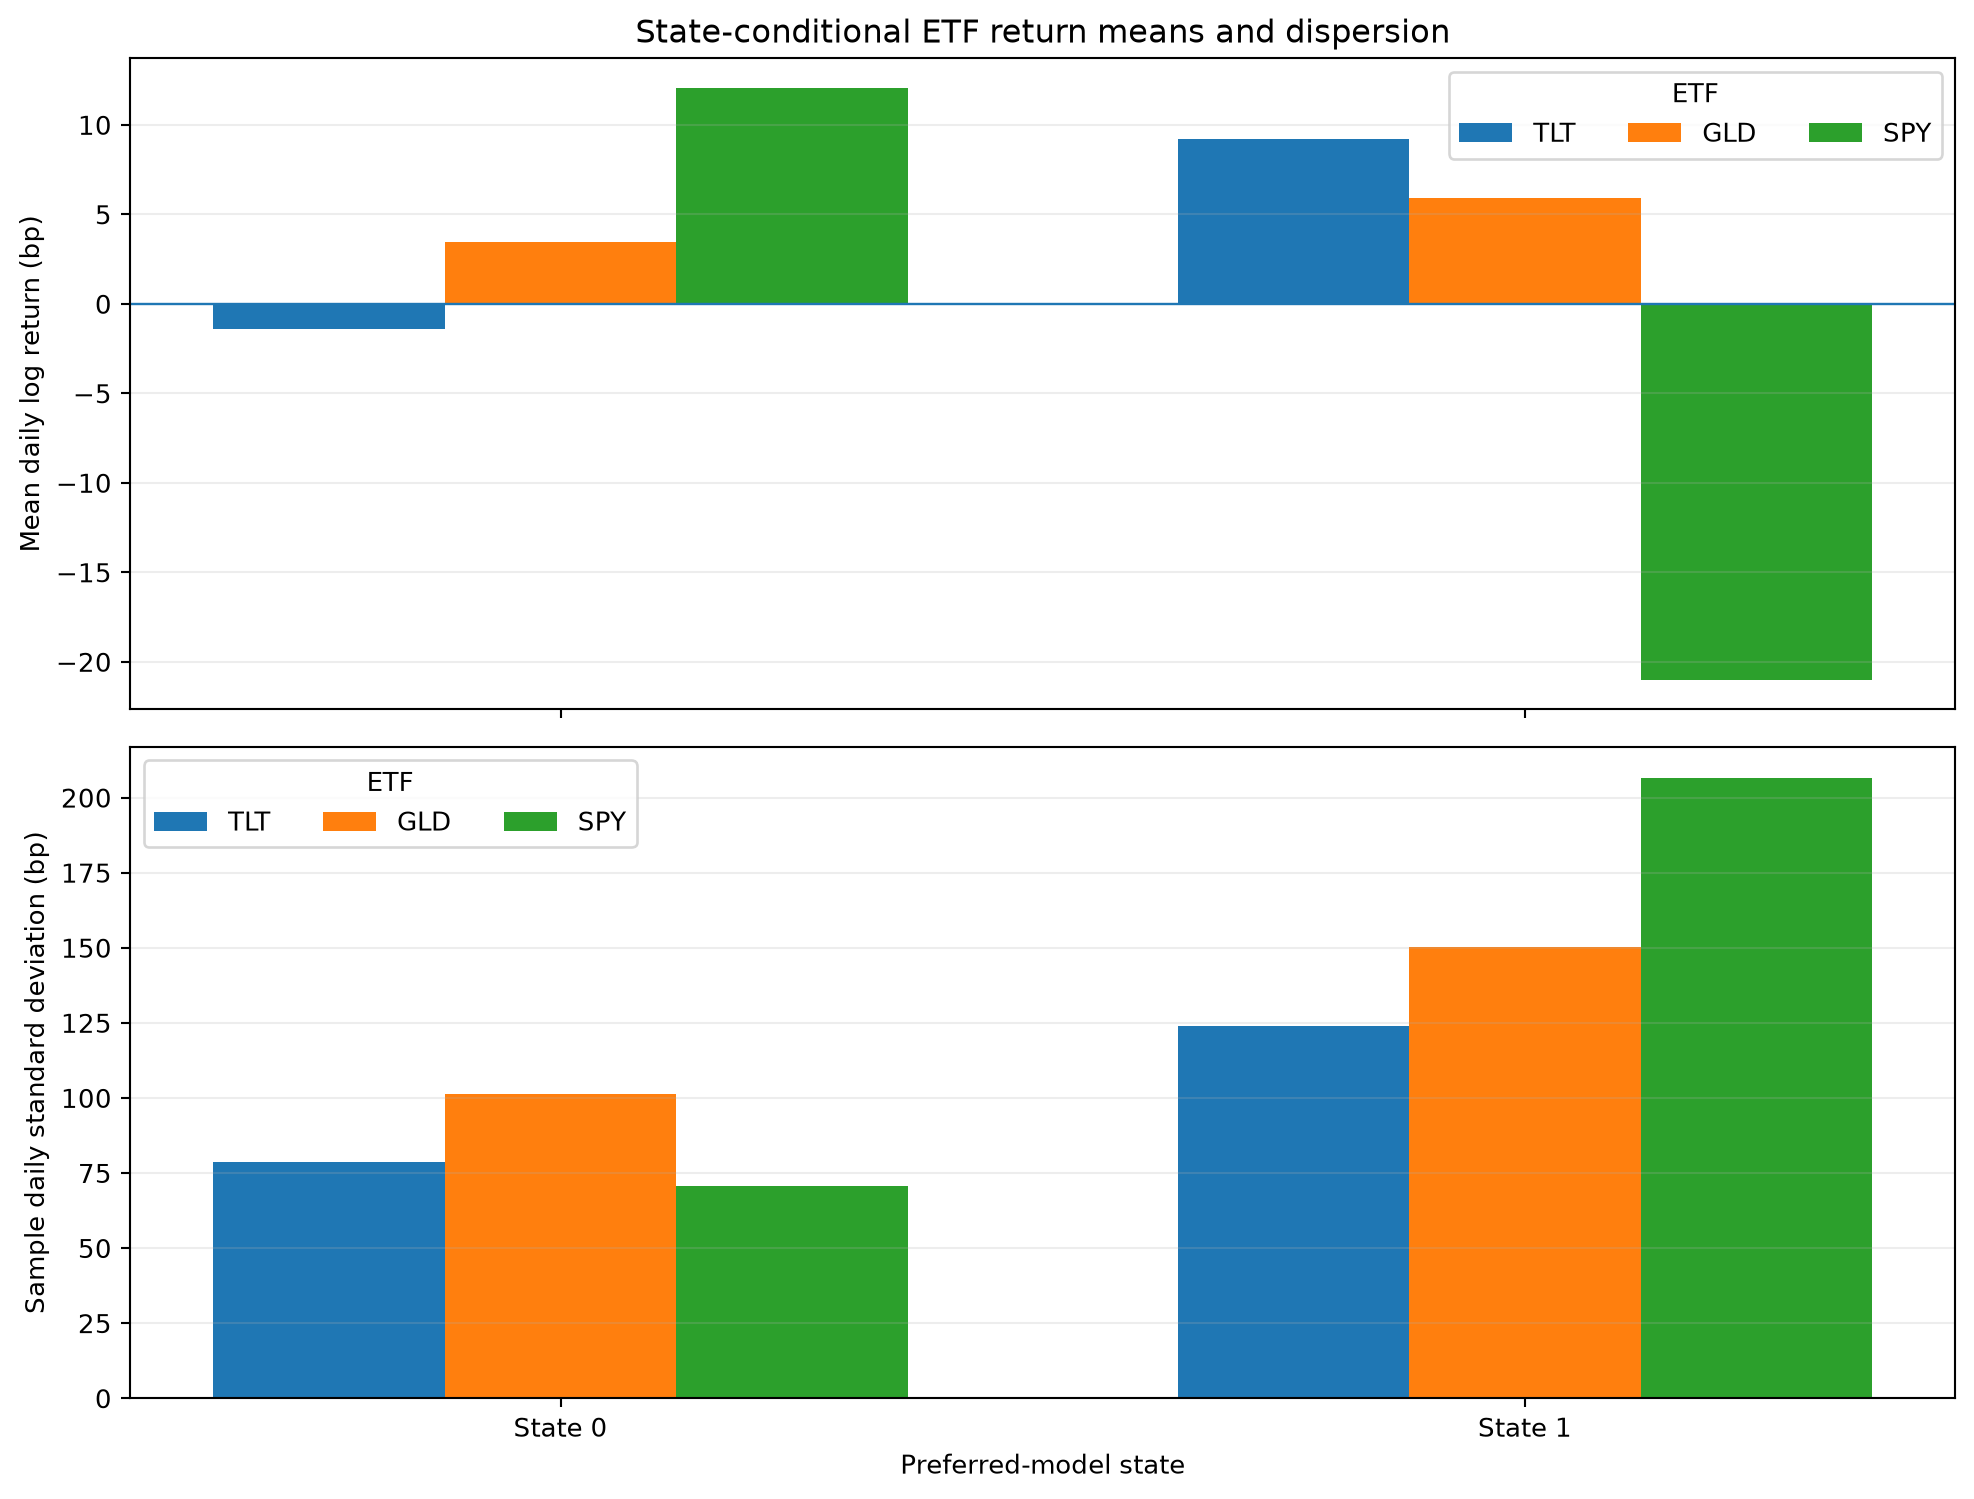

In [5]:
nb.step_3_hmm_selection()


# Step 4 — State-conditional ETF allocation

For every state of the selected HMM, TLT, GLD, and SPY are ranked by descending historical state-conditional mean daily log return. Exact equal means use the fixed priority **TLT → GLD → SPY**. Both assignment allocation methods use the same ranking:

- **100% Keep:** 100% to rank 1, 0% to ranks 2 and 3.
- **60/40 Spread:** 60% to rank 1, 40% to rank 2, 0% to rank 3.

The weights are long-only, finite, and sum to one. The ranking is an in-sample descriptive allocation rule, not a mean-variance optimizer. Concentrating on the historical top-ranked asset can increase estimation and concentration risk; diversification is therefore a relevant economic interpretation when comparing the two rules (Markowitz 77–91).


In [6]:
nb.step_4_dual_allocations()


,method,state,rank_1_asset,rank_2_asset,rank_1_mean_log_return,rank_2_mean_log_return,TLT_weight,GLD_weight,SPY_weight
0,100_keep,0,SPY,GLD,0.12%,0.03%,0.00%,0.00%,100.00%
1,100_keep,1,TLT,GLD,0.09%,0.06%,100.00%,0.00%,0.00%


,method,state,rank_1_asset,rank_2_asset,rank_1_mean_log_return,rank_2_mean_log_return,TLT_weight,GLD_weight,SPY_weight
0,60_40_spread,0,SPY,GLD,0.12%,0.03%,0.00%,40.00%,60.00%
1,60_40_spread,1,TLT,GLD,0.09%,0.06%,60.00%,40.00%,0.00%


# Step 5 — Backtest and benchmark comparison

## 5.1 Execution convention

ETF log returns are converted to simple returns before portfolio arithmetic:

$$
r^{simple}_{i,t}=\exp(r^{log}_{i,t})-1.
$$

For both HMM allocation methods, the state recorded on row $t-1$ determines the weights applied to ETF simple returns on row $t$. The first row is excluded. This one-row execution lag prevents same-row state execution.

The two required benchmarks are:

1. **Equal-weight monthly:** one-third TLT, one-third GLD, and one-third SPY at the start and at the first comparison date of each new calendar month, with weights drifting inside the month.
2. **SPY buy-and-hold:** the aligned SPY simple-return series.

All four portfolio return series use exactly the same dates.

## 5.2 Performance metrics

The evaluation reports exactly five metrics for each portfolio: cumulative return, annualized return, annualized volatility, Sharpe ratio, and maximum drawdown. Annualization uses 252 trading days, the Sharpe calculation uses a zero risk-free rate and sample standard deviation, and drawdown starts from initial wealth $W_0=1$.

The cumulative-performance figure is the primary visual comparison because it places both HMM allocation rules and both required benchmarks on the same wealth-growth scale. The numerical table should be read jointly with drawdown and volatility rather than as a return-only ranking.


### Step 5 — One-observation-lag portfolio comparison

,portfolio,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,observations
0,hmm_100_keep,4662.96%,19.50%,14.21%,1.33,-19.54%,5464
1,hmm_60_40_spread,2667.46%,16.55%,11.93%,1.34,-16.42%,5464
2,equal_weight_monthly,542.08%,8.95%,9.71%,0.93,-23.04%,5464
3,spy_buy_hold,879.81%,11.10%,18.88%,0.65,-55.19%,5464


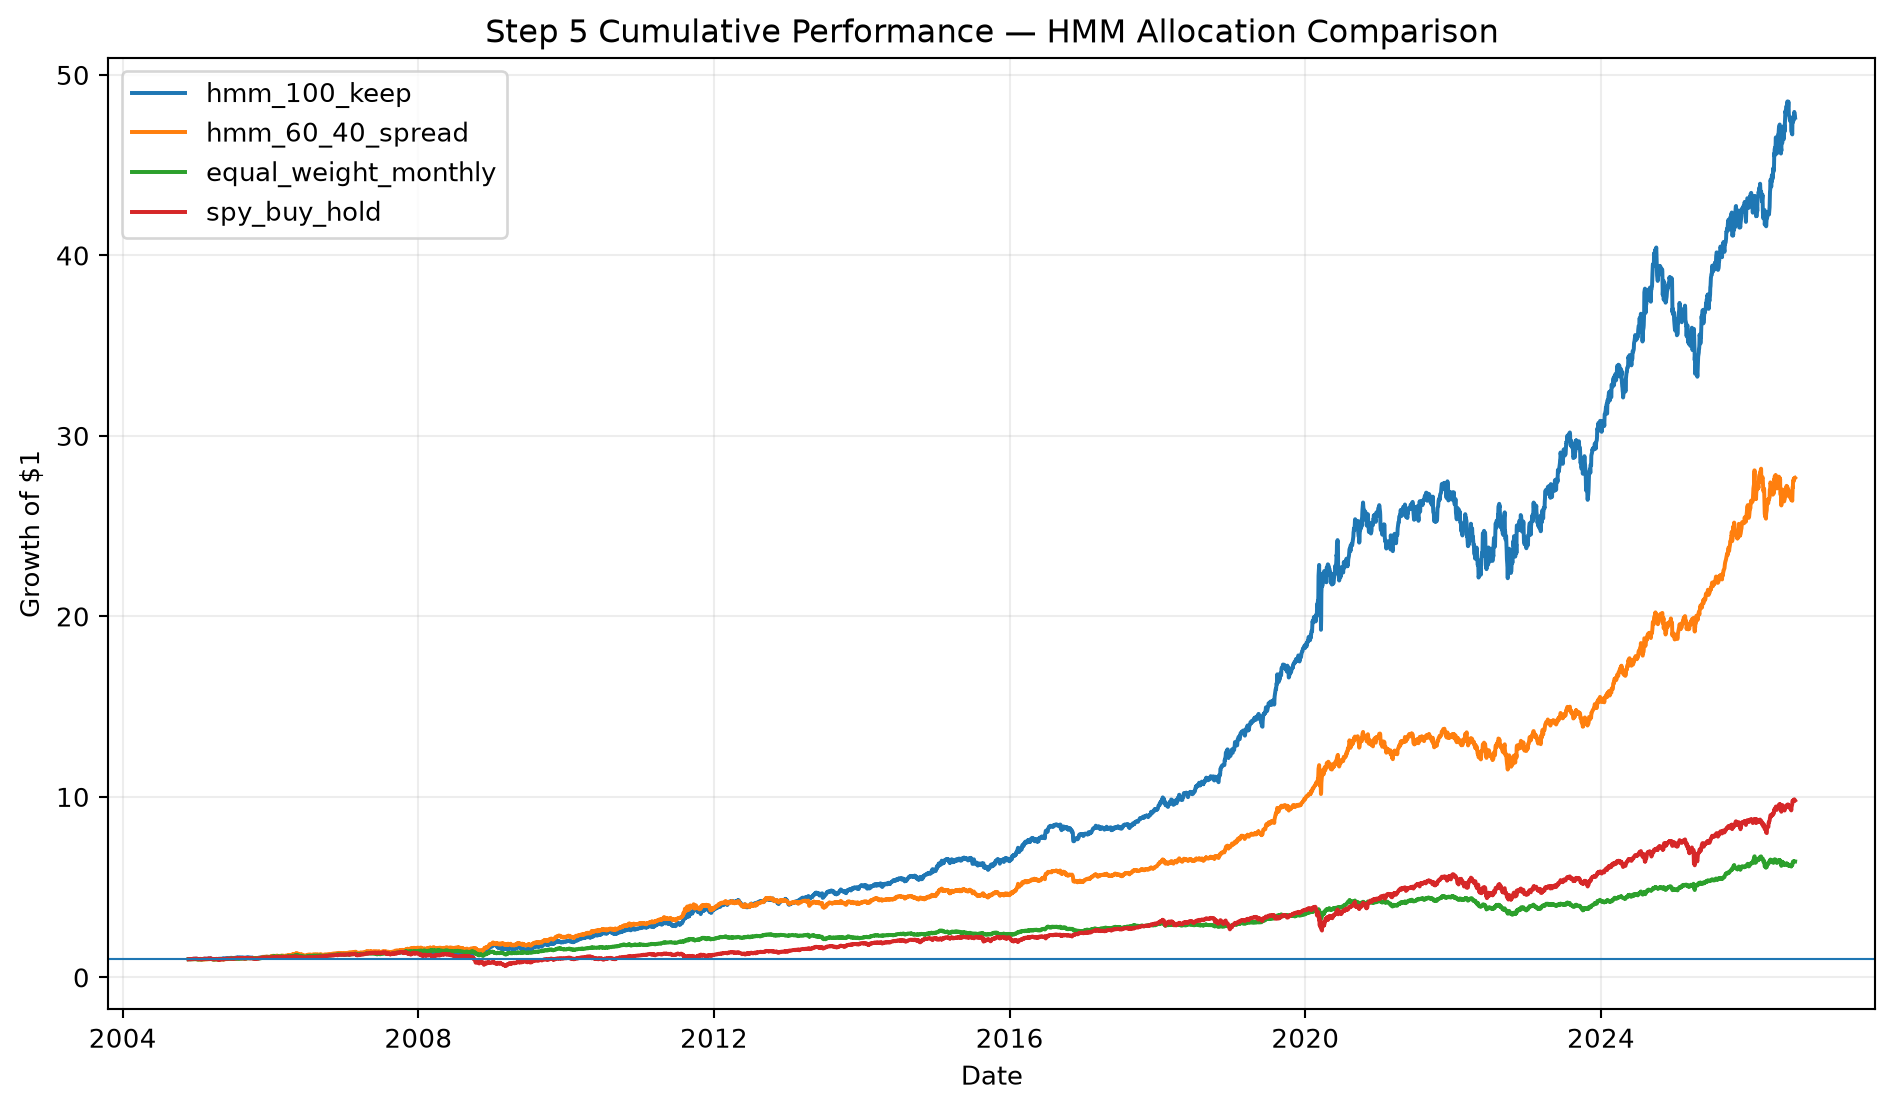

In [7]:
nb.step_5_hmm_dual_method_comparison()


## 5.3 State-count × allocation-method sensitivity

The sensitivity analysis crosses HMM state counts $K=2$ and $K=3$ with both allocation methods, producing exactly four rows. It reuses the persisted HMM candidate state paths, the common lagged return-date intersection, the same state-statistics/ranking logic, the same backtest engine, and the same performance metrics.

Sensitivity is diagnostic rather than a second model-selection rule: a $K=3$ row may be shown even if that candidate fails the 5% main-selection occupancy requirement. The selected Step 3 model remains unchanged.


In [8]:
sensitivity_nb.step_5_state_count_sensitivity()


### Step 5 — HMM state-count and allocation-method sensitivity

,family,n_states,method,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,observations
0,hmm,2,100_keep,4662.96%,19.50%,14.21%,1.33,-19.54%,5464
1,hmm,2,60_40_spread,2667.46%,16.55%,11.93%,1.34,-16.42%,5464
2,hmm,3,100_keep,3589.47%,18.11%,15.48%,1.15,-24.01%,5464
3,hmm,3,60_40_spread,2015.40%,15.11%,12.11%,1.22,-19.66%,5464


# Interpretation, limitations, and conclusions

## Look-ahead limitation

The one-row execution lag removes same-row execution, but it **does not make this full-sample exercise causal**. Three core components use information unavailable at earlier historical dates:

- HMM parameters are estimated on the full sample.
- Viterbi decoding and smoothed posterior probabilities use the full observation sequence.
- State-conditional ETF rankings are computed from full-sample state assignments and returns.

Consequently, the reported results are **assignment backtest results**, not evidence of a deployable live trading edge. A production study would need expanding or rolling re-estimation, one-sided state inference, training-only asset ranking, and a strictly held-out evaluation period.

## Statistical interpretation

Trying alternative state counts and allocation rules creates model-selection and data-snooping risk. Backtest performance can be overstated when the same data influence specification choices and evaluation (White 1097–1126). Sharpe ratios are also vulnerable to selection bias, backtest overfitting, and non-normal return distributions when many alternatives are investigated (Bailey and Lopez de Prado 94–107). The four-row sensitivity table is therefore evidence about robustness within the assignment design, not a multiple-testing correction.

## Conclusion

This revision isolates the analysis to one coherent regime framework: Gaussian HMMs on VIX changes. It distinguishes estimation, joint-path decoding, and smoothed posterior inference; selects only between $K=2$ and $K=3$ HMM candidates under fixed validity and BIC rules; and evaluates both required allocation mappings against identical-date benchmarks. The central empirical comparison is intentionally transparent: **HMM 100% Keep**, **HMM 60/40 Spread**, **monthly equal weight**, and **SPY buy-and-hold**, with the same five performance metrics and a state-count × allocation sensitivity check.

The analysis should therefore be interpreted as a reproducible retrospective study of regime-conditioned allocation mechanics. Its strongest methodological result is not a claim of forecastability, but a clear separation between what the HMM estimates, how state information is decoded, how allocations are constructed, and where full-sample information creates look-ahead bias.


# Works Cited — MLA 9

Akaike, Hirotugu. “A New Look at the Statistical Model Identification.” *IEEE Transactions on Automatic Control*, vol. 19, no. 6, 1974, pp. 716–723. doi:10.1109/TAC.1974.1100705.

Bailey, David H., and Marcos Lopez de Prado. “The Deflated Sharpe Ratio: Correcting for Selection Bias, Backtest Overfitting, and Non-Normality.” *The Journal of Portfolio Management*, vol. 40, no. 5, 2014, pp. 94–107. doi:10.3905/jpm.2014.40.5.094.

Baum, Leonard E., et al. “A Maximization Technique Occurring in the Statistical Analysis of Probabilistic Functions of Markov Chains.” *The Annals of Mathematical Statistics*, vol. 41, no. 1, 1970, pp. 164–171. doi:10.1214/aoms/1177697196.

Markowitz, Harry. “Portfolio Selection.” *The Journal of Finance*, vol. 7, no. 1, 1952, pp. 77–91. doi:10.1111/j.1540-6261.1952.tb01525.x.

Rabiner, Lawrence R. “A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition.” *Proceedings of the IEEE*, vol. 77, no. 2, 1989, pp. 257–286. doi:10.1109/5.18626.

Schwarz, Gideon. “Estimating the Dimension of a Model.” *The Annals of Statistics*, vol. 6, no. 2, 1978, pp. 461–464. doi:10.1214/aos/1176344136.

Viterbi, Andrew J. “Error Bounds for Convolutional Codes and an Asymptotically Optimum Decoding Algorithm.” *IEEE Transactions on Information Theory*, vol. 13, no. 2, 1967, pp. 260–269. doi:10.1109/TIT.1967.1054010.

Whaley, Robert E. “Understanding the VIX.” *The Journal of Portfolio Management*, vol. 35, no. 3, 2009, pp. 98–105. doi:10.3905/JPM.2009.35.3.098.

White, Halbert. “A Reality Check for Data Snooping.” *Econometrica*, vol. 68, no. 5, 2000, pp. 1097–1126. doi:10.1111/1468-0262.00152.

The machine-readable bibliography registry used by the repository is exposed below.


In [9]:
nb.canonical_works_cited()


Bibliography registry: `reports/references.bib`